## Import Modules

In [1]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname,filename))

In [2]:
import sys
print(sys.executable)


c:\Users\lenovo\AppData\Local\Programs\Python\Python313\python.exe


In [3]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio
import warnings
warnings.filterwarnings('ignore')

## Load the Dataset

In [5]:
# ---------- Replace the dataset loading cell with this ----------
import os
import pandas as pd
import numpy as np

dataset_root = 'speech dataset'   # change if your dataset lives elsewhere

# Known emotion words (lowercase)
KNOWN_EMOTIONS = ['neutral','happy','sad','angry','fear','disgust']

paths = []
labels = []

def parse_label_from_filename(filename):
    """
    Try to robustly extract emotion from filename:
    1) look for known emotion keyword anywhere in filename
    2) fallback: use last underscore-separated token (existing logic)
    """
    fn_lower = filename.lower()
    for emo in KNOWN_EMOTIONS:
        if emo in fn_lower:
            return emo
    # fallback: previous approach (still lowercase)
    try:
        lab = filename.split('_')[-1].split('.')[0].lower()
        return lab
    except:
        return 'unknown'

# Walk dataset
for dirname, _, filenames in os.walk(dataset_root):
    for filename in filenames:
        if not filename.lower().endswith(('.wav','.flac','.mp3','.aiff','.ogg')):
            continue
        full = os.path.join(dirname, filename)
        label = parse_label_from_filename(filename)
        paths.append(full)
        labels.append(label)
    # optional break if you intentionally limited dataset earlier
    # if len(paths) == 2800:
    #     break

# Make a DataFrame and do quick sanity checks
df = pd.DataFrame({'speech': paths, 'labels': labels})
print("Total files found:", len(df))

# Show counts per label so you can see if 'happy' exists and how many
print(df['labels'].value_counts())

# Print a few examples for manual verification
print("\nSample files and labels:")
display(df.sample(min(10, len(df))).reset_index(drop=True))


Total files found: 2800
labels
angry      400
disgust    400
fear       400
happy      400
neutral    400
ps         400
sad        400
Name: count, dtype: int64

Sample files and labels:


,speech,labels
0,speech dataset\TESS Toronto emotional speech s...,angry
1,speech dataset\TESS Toronto emotional speech s...,happy
2,speech dataset\TESS Toronto emotional speech s...,disgust
3,speech dataset\TESS Toronto emotional speech s...,happy
4,speech dataset\TESS Toronto emotional speech s...,happy
5,speech dataset\TESS Toronto emotional speech s...,sad
6,speech dataset\TESS Toronto emotional speech s...,disgust
7,speech dataset\TESS Toronto emotional speech s...,fear
8,speech dataset\TESS Toronto emotional speech s...,happy
9,speech dataset\TESS Toronto emotional speech s...,ps


In [6]:
# ---------- After loading dataset, add this analysis ----------
print("\n" + "="*60)
print("DATA ANALYSIS & PREPARATION")
print("="*60)

# Check and clean labels
print("\nUnique labels before cleaning:", df['labels'].unique())
print("\nLabel counts before cleaning:")
print(df['labels'].value_counts())

# Clean the labels - handle 'ps' and 'calm'
df['labels'] = df['labels'].replace({'ps': 'surprise'})  # Map 'ps' to 'surprise'
df['labels'] = df['labels'].replace({'calm': 'neutral'})  # Map 'calm' to 'neutral'

print("\nUnique labels after cleaning:", df['labels'].unique())
print("\nLabel counts after cleaning:")
print(df['labels'].value_counts())

# Keep only main emotions
main_emotions = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
df = df[df['labels'].isin(main_emotions)].copy()

print(f"\nFiltered dataset size: {len(df)}")
print("\nFinal label counts:")
print(df['labels'].value_counts())


DATA ANALYSIS & PREPARATION

Unique labels before cleaning: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'ps' 'sad']

Label counts before cleaning:
labels
angry      400
disgust    400
fear       400
happy      400
neutral    400
ps         400
sad        400
Name: count, dtype: int64

Unique labels after cleaning: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'surprise' 'sad']

Label counts after cleaning:
labels
angry       400
disgust     400
fear        400
happy       400
neutral     400
surprise    400
sad         400
Name: count, dtype: int64

Filtered dataset size: 2800

Final label counts:
labels
angry       400
disgust     400
fear        400
happy       400
neutral     400
surprise    400
sad         400
Name: count, dtype: int64


In [5]:
# paths = []
# labels = []
# for dirname, _, filenames in os.walk('speech dataset'):
#     for filename in filenames:
#         paths.append(os.path.join(dirname, filename))
        
#         label = filename.split('_')[-1]
        
#         label = label.split('.')[0]
#         labels.append(label.lower())
#     if len(paths) == 2800:
#         break
# print('Dataset is Loaded')

In [7]:
len(paths)

2800

In [8]:
paths[:5]

['speech dataset\\TESS Toronto emotional speech set data\\OAF_angry\\OAF_back_angry.wav',
 'speech dataset\\TESS Toronto emotional speech set data\\OAF_angry\\OAF_bar_angry.wav',
 'speech dataset\\TESS Toronto emotional speech set data\\OAF_angry\\OAF_base_angry.wav',
 'speech dataset\\TESS Toronto emotional speech set data\\OAF_angry\\OAF_bath_angry.wav',
 'speech dataset\\TESS Toronto emotional speech set data\\OAF_angry\\OAF_bean_angry.wav']

In [9]:
labels[:5]

['angry', 'angry', 'angry', 'angry', 'angry']

In [10]:
df = pd.DataFrame()
df['speech'] = paths
df['labels'] = labels
df.head()


,speech,labels
0,speech dataset\TESS Toronto emotional speech s...,angry
1,speech dataset\TESS Toronto emotional speech s...,angry
2,speech dataset\TESS Toronto emotional speech s...,angry
3,speech dataset\TESS Toronto emotional speech s...,angry
4,speech dataset\TESS Toronto emotional speech s...,angry


In [11]:
df['labels'].value_counts()


labels
angry      400
disgust    400
fear       400
happy      400
neutral    400
ps         400
sad        400
Name: count, dtype: int64

## Exploratory Data Analysis

<Axes: xlabel='labels', ylabel='count'>

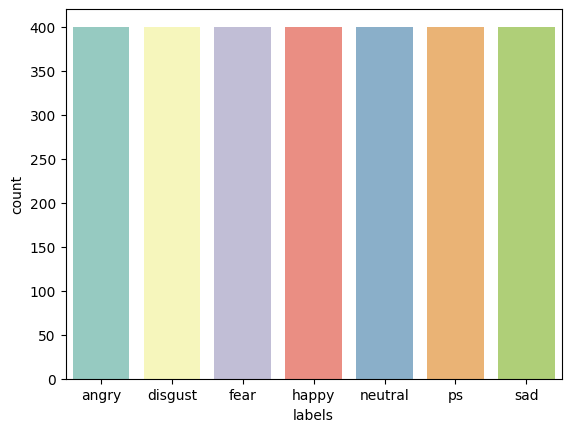

In [12]:
sns.countplot(data=df, x='labels', palette='Set3')


In [13]:
def waveplot(data, sr, emotion):
    plt.figure(figsize=(10,4))
    plt.title(emotion, size=20)
    librosa.display.waveshow(data, sr=sr)
    plt.show()
    
def spectogram(data, sr, emotion):
    x = librosa.stft(data)
    xdb = librosa.amplitude_to_db(abs(x))
    plt.figure(figsize=(11,4))
    plt.title(emotion, size=20)
    librosa.display.specshow(xdb, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar()

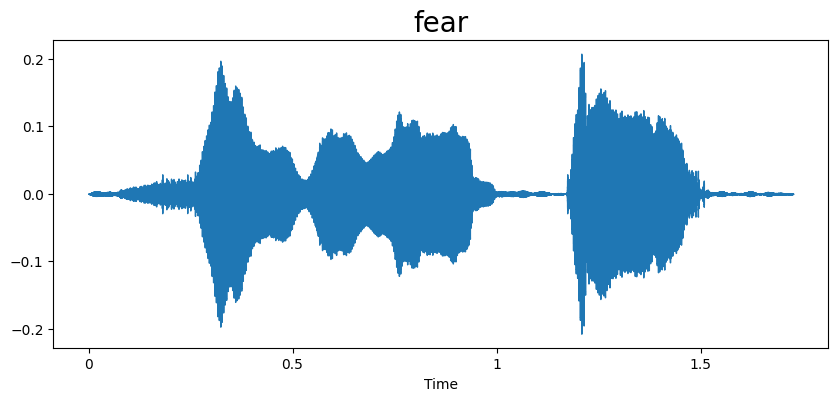

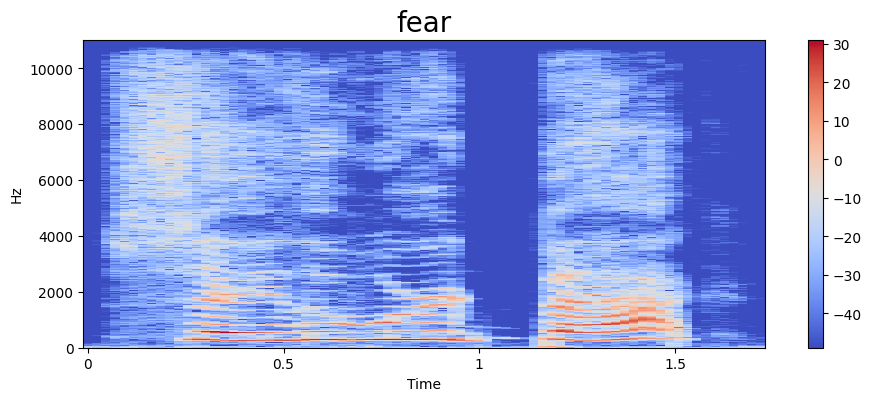

In [12]:
emotion = 'fear'
path = np.array(df['speech'][df['labels']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

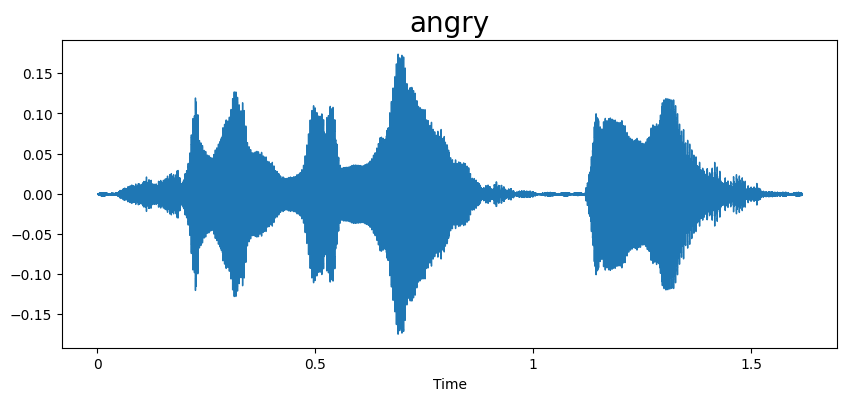

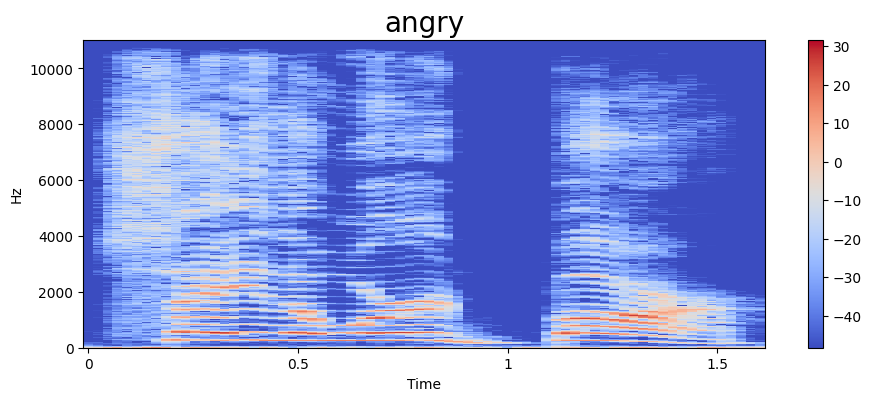

In [13]:
emotion = 'angry'
path = np.array(df['speech'][df['labels']==emotion])[1]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

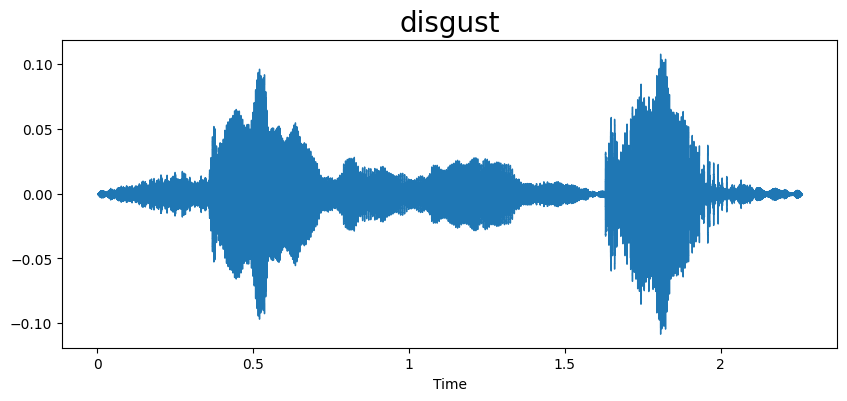

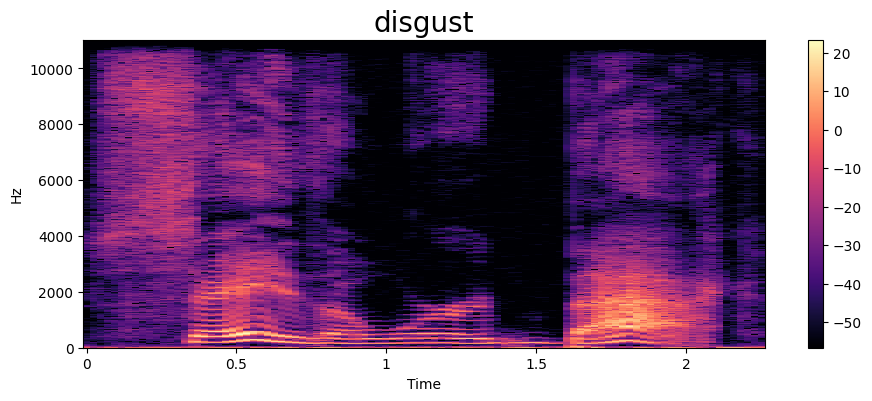

In [14]:
emotion = 'disgust'
path = np.array(df['speech'][df['labels']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

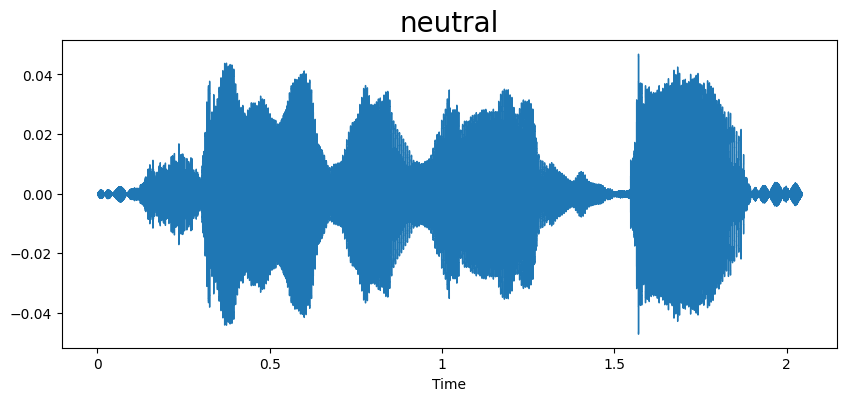

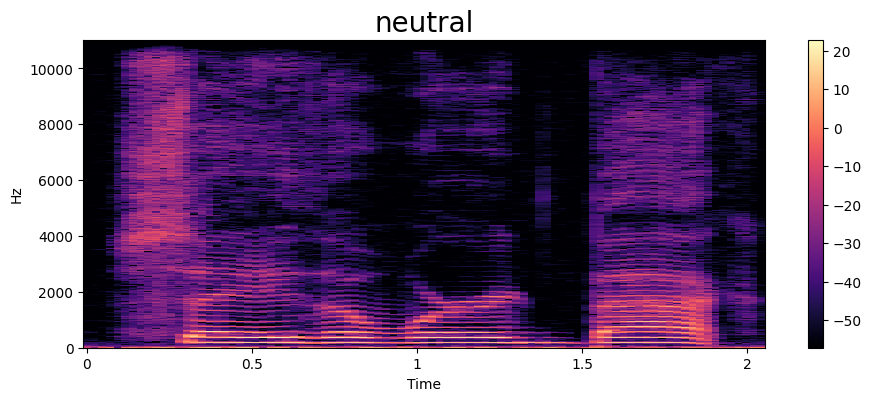

In [15]:
emotion = 'neutral'
path = np.array(df['speech'][df['labels']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

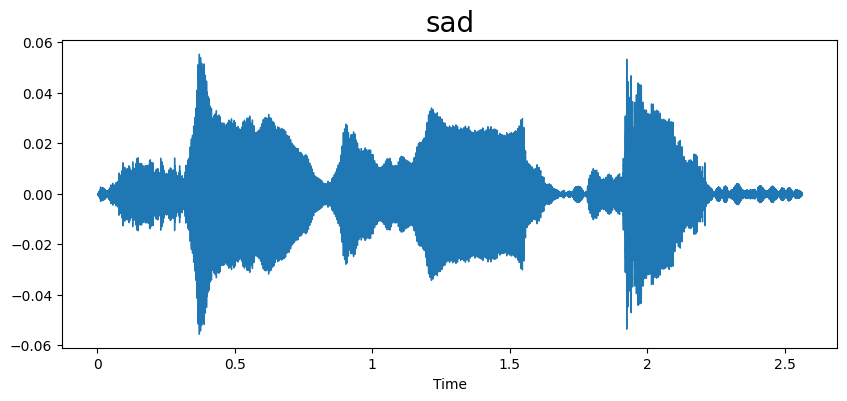

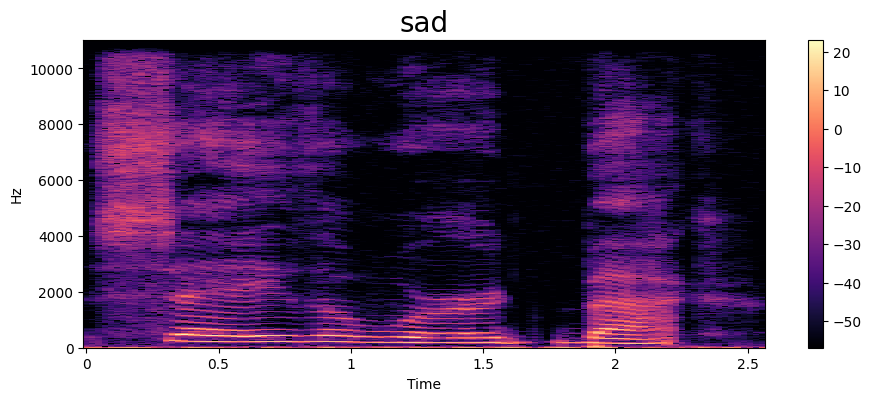

In [16]:
emotion = 'sad'
path = np.array(df['speech'][df['labels']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

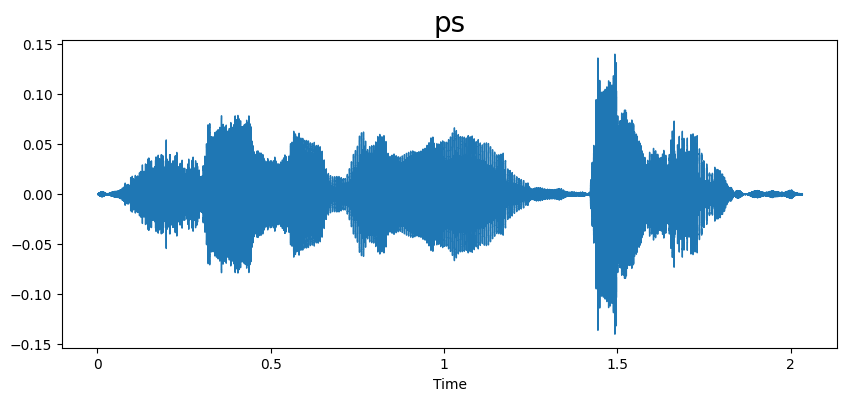

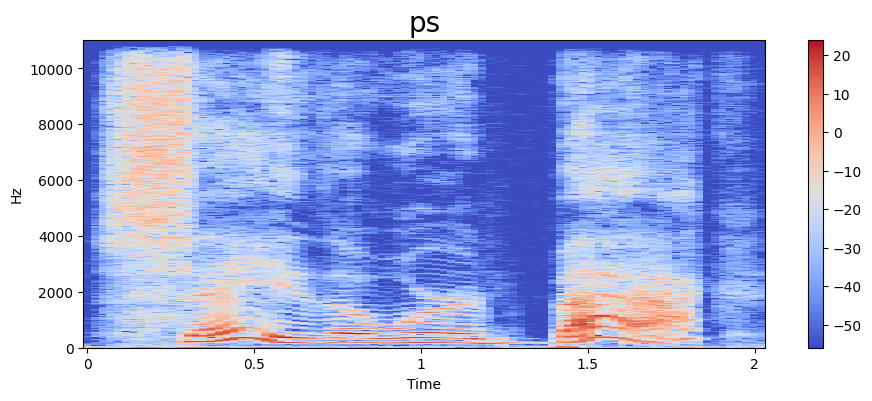

In [17]:
emotion = 'ps'
path = np.array(df['speech'][df['labels']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

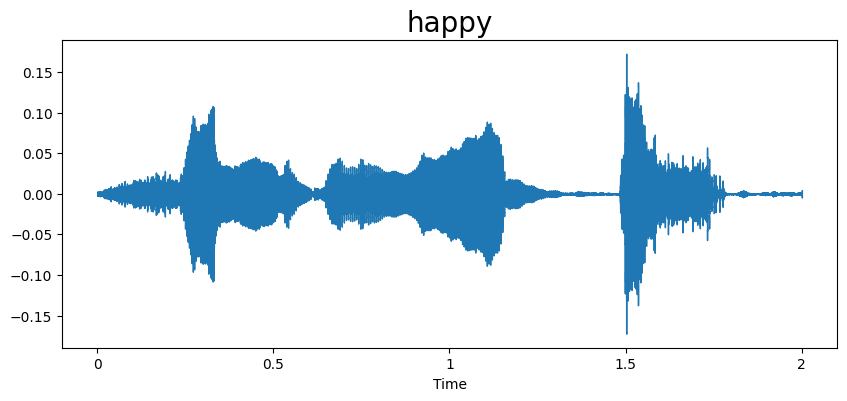

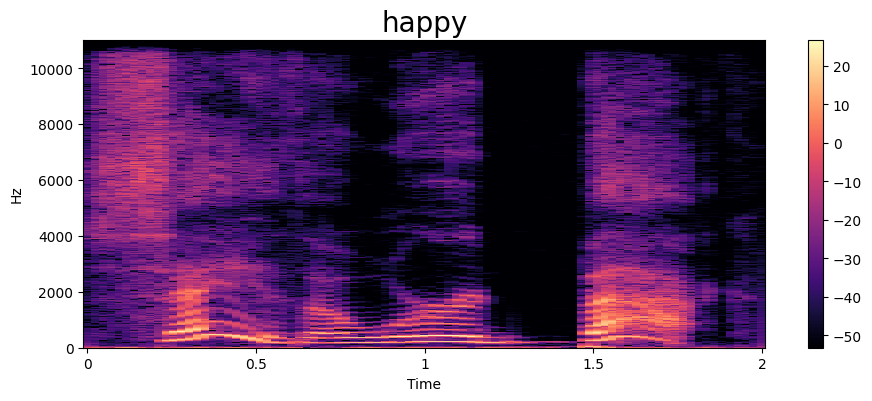

In [18]:
emotion = 'happy'
path = np.array(df['speech'][df['labels']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

## Feature Extraction

In [14]:
def extract_mfcc(filename):
     y, sr = librosa.load(filename, duration=3, offset=0.5)
     mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
     return mfcc

In [15]:
extract_mfcc(df['speech'][0])


array([-3.9698630e+02,  7.7440544e+01, -1.9592793e+01, -2.1666689e+01,
       -2.1127563e+00,  1.0075363e+01, -2.0366709e+01, -6.0924492e+00,
       -7.2122836e+00, -5.5736595e-01, -1.8325537e+00,  2.0210202e-01,
        7.2755092e-01,  1.3177381e+00,  2.8863375e+00,  2.8557916e+00,
       -4.7129202e+00, -4.4365101e+00, -1.6211587e+00, -1.0239840e+01,
       -7.5512633e+00, -1.7968791e+00, -7.0376520e+00,  9.4365845e+00,
        8.3558550e+00,  2.1712360e+01,  1.9216990e+01,  2.0348928e+01,
        1.3413366e+01,  8.3391733e+00,  3.9472249e-01,  5.1113148e+00,
        9.5687399e+00,  5.4548688e+00,  2.5099633e+00, -1.8239070e+00,
        4.8689623e+00,  9.3139238e+00,  2.0891497e+00, -1.9064908e+00],
      dtype=float32)

In [16]:
X_mfcc = df['speech'].apply(lambda x: extract_mfcc(x))


In [17]:
X = [x for x in X_mfcc]
X = np.array(X)
X.shape

(2800, 40)

In [18]:
## input split
X = np.expand_dims(X, -1)
X.shape

(2800, 40, 1)

In [19]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
y = enc.fit_transform(df[['labels']])
y = y.toarray()
y.shape

(2800, 7)

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)


In [21]:
# ---------- After feature extraction, add this ----------
print("\n" + "="*60)
print("FEATURE ANALYSIS")
print("="*60)
print(f"Feature shape: {X.shape}")

# Encode labels
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
y = labelencoder.fit_transform(df['labels'])
emotion_names = labelencoder.classes_

# One-hot encode
from tensorflow.keras.utils import to_categorical
y = to_categorical(y, num_classes=len(emotion_names))
num_labels = y.shape[1]

print(f"\nNumber of emotion classes: {num_labels}")
print(f"Emotion names: {emotion_names}")
print(f"One-hot encoded y shape: {y.shape}")

# Check class balance
class_counts = np.sum(y, axis=0)
print("\nClass distribution:")
for i, emotion in enumerate(emotion_names):
    print(f"{emotion}: {int(class_counts[i])} samples ({class_counts[i]/len(y)*100:.1f}%)")


FEATURE ANALYSIS
Feature shape: (2800, 40, 1)

Number of emotion classes: 7
Emotion names: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'ps' 'sad']
One-hot encoded y shape: (2800, 7)

Class distribution:
angry: 400 samples (14.3%)
disgust: 400 samples (14.3%)
fear: 400 samples (14.3%)
happy: 400 samples (14.3%)
neutral: 400 samples (14.3%)
ps: 400 samples (14.3%)
sad: 400 samples (14.3%)


In [22]:
# ---------- Replace your model creation with this ----------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, GlobalAveragePooling1D, BatchNormalization, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2

def create_balanced_model(input_shape, num_classes):
    """
    Create a balanced model with regularization to prevent overfitting
    """
    model = Sequential()
    
    # First Conv Block
    model.add(Conv1D(64, kernel_size=5, activation='relu', padding='same', 
                     input_shape=input_shape, kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(SpatialDropout1D(0.1))
    model.add(Conv1D(64, kernel_size=5, activation='relu', padding='same',
                     kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.25))
    
    # Second Conv Block
    model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same',
                     kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(SpatialDropout1D(0.15))
    model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same',
                     kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))
    
    # Third Conv Block
    model.add(Conv1D(256, kernel_size=3, activation='relu', padding='same',
                     kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(SpatialDropout1D(0.2))
    model.add(Conv1D(256, kernel_size=3, activation='relu', padding='same',
                     kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.4))
    
    # Global pooling
    model.add(GlobalAveragePooling1D())
    
    # Dense layers
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))
    
    # Output layer
    model.add(Dense(num_classes, activation='softmax'))
    
    # Compile
    model.compile(loss='categorical_crossentropy', 
                  optimizer=Adam(learning_rate=0.0005), 
                  metrics=['accuracy'])
    
    return model

# Create the model
print("\n" + "="*60)
print("CREATING BALANCED MODEL")
print("="*60)
model = create_balanced_model((X.shape[1], 1), num_labels)
model.summary()


CREATING BALANCED MODEL


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 40, 64)         │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 40, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 40, 64)         │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 40, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 20, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 20, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 20, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 10, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 10, 256)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 10, 256)        │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 10, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 5, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 436,295 (1.66 MB)

 Trainable params: 434,119 (1.66 MB)

 Non-trainable params: 2,176 (8.50 KB)

In [ ]:
# #from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, LSTM, Dropout

# model = Sequential([
#     LSTM(256, return_sequences=False, input_shape=(40, 1)),
#     Dropout(0.2),

#     Dense(128, activation='relu'),
#     Dropout(0.2),

#     Dense(64, activation='relu'),
#     Dropout(0.2),

#     Dense(7, activation='softmax')
# ])

# model.compile(
#     loss='categorical_crossentropy',
#     optimizer='adam',
#     metrics=['accuracy']
# )

# model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 256)            │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,799 (1.17 MB)

 Trainable params: 305,799 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# ---------- Add before training ----------
from sklearn.model_selection import train_test_split
import numpy as np

# Stratified split to maintain class distribution
print("\n" + "="*60)
print("STRATIFIED DATA SPLITTING")
print("="*60)

# Get integer labels for stratification
y_integer = np.argmax(y, axis=1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, 
    stratify=y_integer
)

# Further split for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42,
    stratify=np.argmax(y_train, axis=1)
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Calculate balanced class weights
from sklearn.utils.class_weight import compute_class_weight

# Get training integer labels
y_train_integer = np.argmax(y_train, axis=1)

# Calculate class frequencies
class_counts = np.bincount(y_train_integer)
total_samples = len(y_train_integer)
class_frequencies = class_counts / total_samples

print("\nClass distribution in training set:")
for i, emotion in enumerate(emotion_names):
    print(f"{emotion}: {class_counts[i]} samples ({class_frequencies[i]*100:.1f}%)")

# Create smoothed class weights
smoothing_factor = 0.1
smoothed_weights = 1.0 / (class_frequencies + smoothing_factor)
smoothed_weights = smoothed_weights / np.sum(smoothed_weights) * len(class_counts)
class_weight_dict = dict(enumerate(smoothed_weights))

print("\nClass weights (smoothed):")
for i, weight in class_weight_dict.items():
    print(f"{emotion_names[i]}: {weight:.2f}")


STRATIFIED DATA SPLITTING
Training set: 1792 samples
Validation set: 448 samples
Test set: 560 samples

Class distribution in training set:
angry: 256 samples (14.3%)
disgust: 256 samples (14.3%)
fear: 256 samples (14.3%)
happy: 256 samples (14.3%)
neutral: 256 samples (14.3%)
ps: 256 samples (14.3%)
sad: 256 samples (14.3%)

Class weights (smoothed):
angry: 1.00
disgust: 1.00
fear: 1.00
happy: 1.00
neutral: 1.00
ps: 1.00
sad: 1.00


In [24]:
# ---------- Replace training cell with this ----------
print("\n" + "="*60)
print("TRAINING MODEL")
print("="*60)

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=20,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_emotion_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=0
    )
]

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)


TRAINING MODEL
Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.1975 - loss: 3.4519 - val_accuracy: 0.3527 - val_loss: 2.8455 - learning_rate: 5.0000e-04
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3142 - loss: 2.9137 - val_accuracy: 0.2746 - val_loss: 2.6220 - learning_rate: 5.0000e-04
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4375 - loss: 2.4864 - val_accuracy: 0.5982 - val_loss: 2.1761 - learning_rate: 5.0000e-04
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5564 - loss: 2.1445 - val_accuracy: 0.7701 - val_loss: 1.7387 - learning_rate: 5.0000e-04
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5943 - loss: 2.0290 - val_accuracy: 0.8237 - val_loss: 1.4672 - learning_rate: 5.0000e-04
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6696 - loss: 1.8557 - val_accuracy: 0.8638 - val_loss: 1.3836 - learning_rate: 5.0000e-04
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/s


MODEL EVALUATION


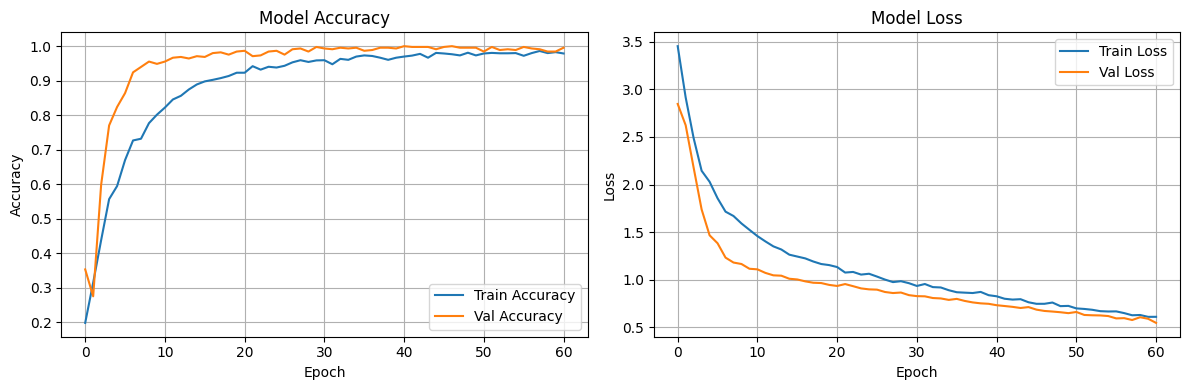


Evaluating on test set...
Test Accuracy: 0.9929
Test Loss: 0.7485
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry       1.00      0.99      0.99        80
     disgust       0.99      1.00      0.99        80
        fear       1.00      1.00      1.00        80
       happy       0.96      1.00      0.98        80
     neutral       1.00      1.00      1.00        80
          ps       1.00      0.97      0.99        80
         sad       1.00      0.99      0.99        80

    accuracy                           0.99       560
   macro avg       0.99      0.99      0.99       560
weighted avg       0.99      0.99      0.99       560



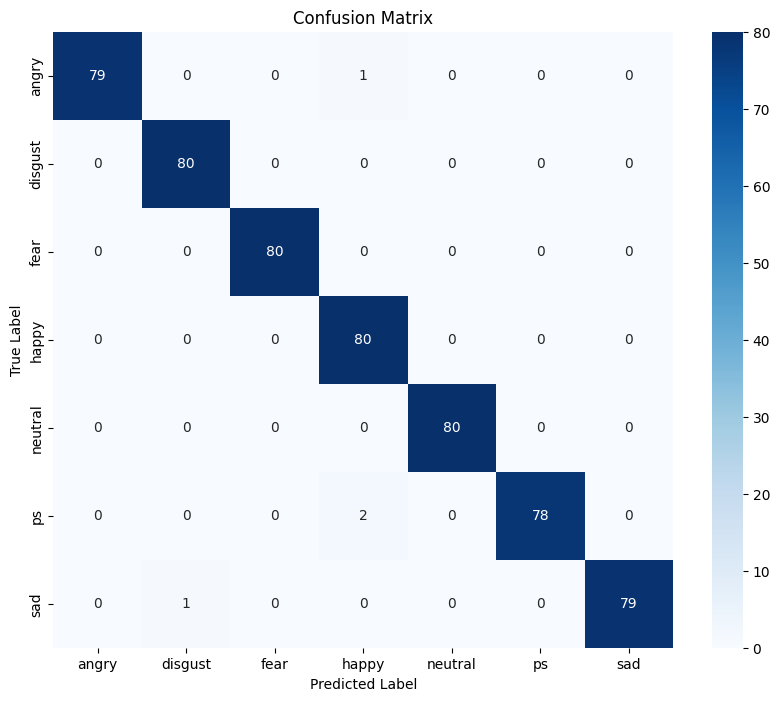


PER-CLASS PERFORMANCE
angry: 98.8% (79/80)
disgust: 100.0% (80/80)
fear: 100.0% (80/80)
happy: 100.0% (80/80)
neutral: 100.0% (80/80)
ps: 97.5% (78/80)
sad: 98.8% (79/80)


In [25]:
# ---------- Add after training ----------
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Evaluate on test set
print("\nEvaluating on test set...")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Detailed classification report
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true_classes, y_pred_classes, 
                           target_names=emotion_names))

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Per-class analysis
print("\n" + "="*60)
print("PER-CLASS PERFORMANCE")
print("="*60)

for i, emotion in enumerate(emotion_names):
    indices = np.where(y_true_classes == i)[0]
    if len(indices) > 0:
        correct = sum(y_pred_classes[indices] == i)
        accuracy = correct / len(indices) * 100
        print(f"{emotion}: {accuracy:.1f}% ({correct}/{len(indices)})")

In [ ]:
# # ---------- Replace the feature extraction cell with this ----------
# import librosa
# import numpy as np

# def extract_features_from_audio(data, sr, n_mfcc=40):
#     """
#     Given waveform (data, sr), return a 1D feature vector consisting of:
#       - mean MFCCs (n_mfcc)
#       - mean MFCC deltas
#       - chroma_stft mean (12)
#       - spectral_contrast mean (7)
#       - tonnetz mean (6)
#     """
#     result = np.array([], dtype=np.float32)

#     # MFCCs
#     mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=n_mfcc)
#     mfcc_mean = np.mean(mfcc, axis=1)
#     result = np.hstack((result, mfcc_mean))

#     # MFCC deltas (first derivative)
#     mfcc_delta = librosa.feature.delta(mfcc)
#     mfcc_delta_mean = np.mean(mfcc_delta, axis=1)
#     result = np.hstack((result, mfcc_delta_mean))

#     # Chroma (requires STFT)
#     try:
#         chroma = librosa.feature.chroma_stft(y=data, sr=sr)
#         chroma_mean = np.mean(chroma, axis=1)
#         result = np.hstack((result, chroma_mean))
#     except Exception as e:
#         # if chroma fails, pad with zeros
#         result = np.hstack((result, np.zeros(12)))

#     # Spectral contrast
#     try:
#         spec_contrast = librosa.feature.spectral_contrast(y=data, sr=sr)
#         spec_contrast_mean = np.mean(spec_contrast, axis=1)
#         result = np.hstack((result, spec_contrast_mean))
#     except:
#         result = np.hstack((result, np.zeros(7)))

#     # Tonnetz (requires harmonic component)
#     try:
#         harmonic = librosa.effects.harmonic(y=data)
#         tonnetz = librosa.feature.tonnetz(y=harmonic, sr=sr)
#         tonnetz_mean = np.mean(tonnetz, axis=1)
#         result = np.hstack((result, tonnetz_mean))
#     except:
#         result = np.hstack((result, np.zeros(6)))

#     return result

# def get_features(path):
#     """
#     Load file, resample if needed, trim silence, and return features vector.
#     """
#     data, sr = librosa.load(path, sr=22050, mono=True)  # standard sr
#     # optional: trim leading/trailing silence
#     data, _ = librosa.effects.trim(data)
#     features = extract_features_from_audio(data, sr)
#     return features

# # Build X, Y using the get_features above (replace any earlier loop)
# X, Y = [], []
# for idx, (path, label) in enumerate(zip(df['speech'], df['labels'])):
#     try:
#         feats = get_features(path)
#         X.append(feats)
#         Y.append(label)
#     except Exception as e:
#         print(f"Skipping {path} (error: {e})")

# X = np.array(X)
# Y = np.array(Y)
# print("X shape:", X.shape, "Y shape:", Y.shape)


X shape: (5600, 105) Y shape: (5600,)


In [26]:
#Feature extraction functions
def extract_features(data, sr):
    """
    Extract audio features:
    - MFCC (Mel-Frequency Cepstral Coefficients)
    - Chroma
    - Mel Spectrogram
    - Spectral Contrast
    - Tonnetz
    """
    # Extract features
    result = np.array([])
    
    # MFCCs
    mfcc = np.mean(librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T, axis=0)
    result = np.hstack((result, mfcc))
    
    # Chroma
    chroma = np.mean(librosa.feature.chroma_stft(y=data, sr=sr).T, axis=0)
    result = np.hstack((result, chroma))
    
    # Mel Spectrogram
    mel = np.mean(librosa.feature.melspectrogram(y=data, sr=sr).T, axis=0)
    result = np.hstack((result, mel))
    
    # Spectral Contrast
    contrast = np.mean(librosa.feature.spectral_contrast(y=data, sr=sr).T, axis=0)
    result = np.hstack((result, contrast))
    
    # Tonnetz
    tonnetz = np.mean(librosa.feature.tonnetz(y=librosa.effects.harmonic(data), sr=sr).T, axis=0)
    result = np.hstack((result, tonnetz))
    
    return result

def get_features(path):
    """
    Extract features from an audio file
    """
    # Load audio file
    data, sr = librosa.load(path, duration=2.5, offset=0.6)
    
    # Extract features
    features = extract_features(data, sr)
    
    return features

# Extract features for all audio files
X, Y = [], []
for path, label in zip(df['speech'], df['labels']):
    try:
        features = get_features(path)
        X.append(features)
        Y.append(label)
    except Exception as e:
        print(f"Error processing {path}: {e}")

# Convert to numpy arrays
X = np.array(X)
Y = np.array(Y)
print(f"Features shape: {X.shape}")
print(f"Labels shape: {Y.shape}")

Features shape: (2800, 193)
Labels shape: (2800,)


In [28]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Encode labels
le = LabelEncoder()
Y_encoded = le.fit_transform(Y)
print(f"Classes: {le.classes_}")
print(f"Encoded labels: {np.unique(Y_encoded)}")

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, Y_encoded, 
    test_size=0.2, 
    random_state=42,
    stratify=Y_encoded
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Classes: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'ps' 'sad']
Encoded labels: [0 1 2 3 4 5 6]
Training set: (4480, 193)
Testing set: (1120, 193)


Random Forest:
  Accuracy: 0.9982
  Training Score: 1.0000
--------------------------------------------------
SVM:
  Accuracy: 0.9964
  Training Score: 0.9987
--------------------------------------------------
KNN:
  Accuracy: 0.9893
  Training Score: 0.9933
--------------------------------------------------
Gradient Boosting:
  Accuracy: 1.0000
  Training Score: 1.0000
--------------------------------------------------
XGBoost:
  Accuracy: 0.9982
  Training Score: 1.0000
--------------------------------------------------
Neural Network:
  Accuracy: 0.9964
  Training Score: 1.0000
--------------------------------------------------

Model Performance:
               Model  Accuracy
3  Gradient Boosting  1.000000
0      Random Forest  0.998214
4            XGBoost  0.998214
1                SVM  0.996429
5     Neural Network  0.996429
2                KNN  0.989286


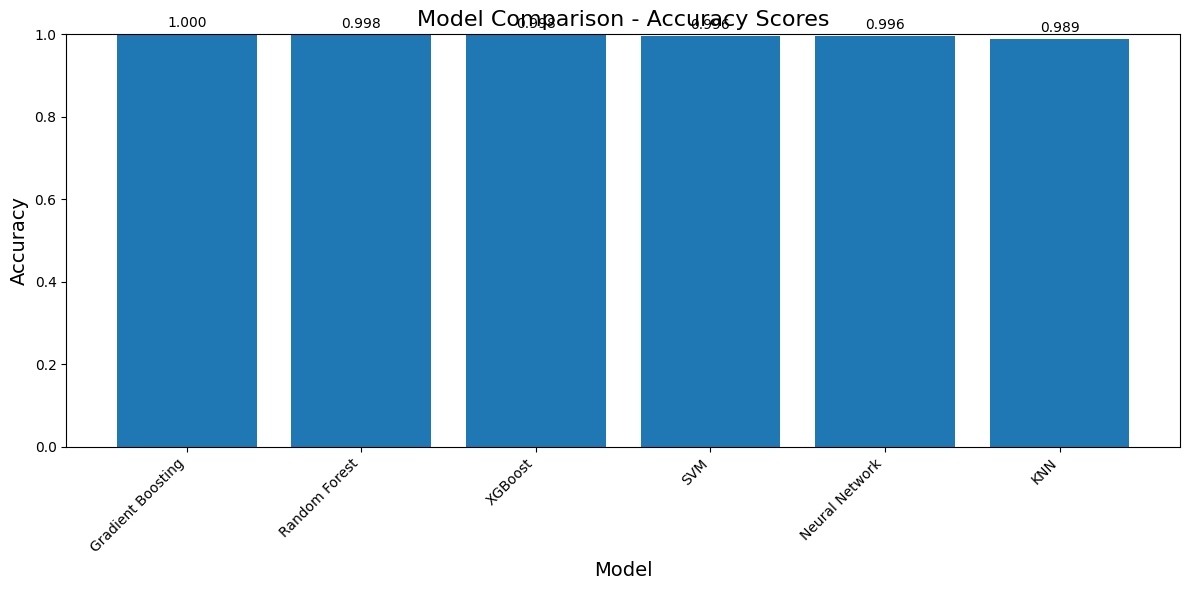

In [29]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb

# Dictionary of models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(256, 128), 
                                     max_iter=500, 
                                     random_state=42)
}

# Train and evaluate models
results = {}
for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    
    # Print results
    print(f"{name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Training Score: {model.score(X_train, y_train):.4f}")
    print("-" * 50)

# Display results
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values('Accuracy', ascending=False)
print("\nModel Performance:")
print(results_df)

# Plot model comparison
plt.figure(figsize=(12, 6))
bars = plt.bar(results_df['Model'], results_df['Accuracy'])
plt.title('Model Comparison - Accuracy Scores', fontsize=16)
plt.xlabel('Model', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')

# Add accuracy values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 1, 128)         │       164,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 216,583 (846.03 KB)

 Trainable params: 216,583 (846.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6855 - loss: 1.0843 - val_accuracy: 0.9531 - val_loss: 0.2640
Epoch 2/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9425 - loss: 0.1956 - val_accuracy: 0.9866 - val_loss: 0.0462
Epoch 3/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9886 - loss: 0.0579 - val_accuracy: 0.9955 - val_loss: 0.0139
Epoch 4/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9914 - loss: 0.0348 - val_accuracy: 0.9955 - val_loss: 0.0106
Epoch 5/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9980 - loss: 0.0152 - val_accuracy: 0.9989 - val_loss: 0.0055
Epoch 6/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9961 - loss: 0.0149 - val_accuracy: 0.9989 - val_loss: 0.0047
Epoch 7/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9969 - loss: 0.0111 - val_accuracy: 0.9978 - val_loss: 0.0059
Epoch 8/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9964 - loss: 0.0134 - val_accuracy: 0.

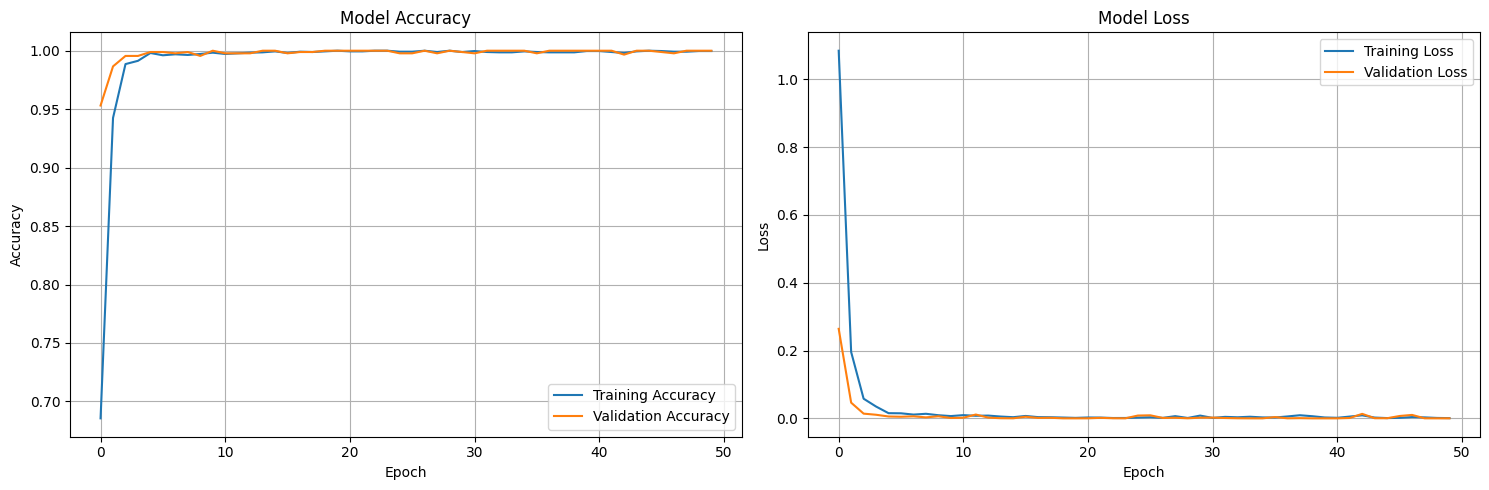

In [ ]:
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers, models
# from tensorflow.keras.utils import to_categorical

# # Reshape data for LSTM (samples, timesteps, features)
# X_lstm = X_scaled.reshape(X_scaled.shape[0], 1, X_scaled.shape[1])

# # One-hot encode labels
# y_onehot = to_categorical(Y_encoded)

# # Split for LSTM
# X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
#     X_lstm, y_onehot, 
#     test_size=0.2, 
#     random_state=42,
#     stratify=Y_encoded
# )

# # Build LSTM model
# lstm_model = models.Sequential([
#     layers.LSTM(128, return_sequences=True, input_shape=(1, X_scaled.shape[1])),
#     layers.Dropout(0.3),
#     layers.LSTM(64),
#     layers.Dropout(0.3),
#     layers.Dense(32, activation='relu'),
#     layers.Dropout(0.2),
#     layers.Dense(len(le.classes_), activation='softmax')
# ])

# # Compile model
# lstm_model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=0.001),
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# # Print model summary
# lstm_model.summary()

# # Train LSTM model
# history = lstm_model.fit(
#     X_train_lstm, y_train_lstm,
#     validation_split=0.2,
#     epochs=50,
#     batch_size=32,
#     verbose=1
# )

# # Evaluate LSTM model
# lstm_loss, lstm_accuracy = lstm_model.evaluate(X_test_lstm, y_test_lstm, verbose=0)
# print(f"\nLSTM Model Accuracy: {lstm_accuracy:.4f}")

# # Plot training history
# fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# # Plot accuracy
# axes[0].plot(history.history['accuracy'], label='Training Accuracy')
# axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
# axes[0].set_title('Model Accuracy')
# axes[0].set_xlabel('Epoch')
# axes[0].set_ylabel('Accuracy')
# axes[0].legend()
# axes[0].grid(True)

# # Plot loss
# axes[1].plot(history.history['loss'], label='Training Loss')
# axes[1].plot(history.history['val_loss'], label='Validation Loss')
# axes[1].set_title('Model Loss')
# axes[1].set_xlabel('Epoch')
# axes[1].set_ylabel('Loss')
# axes[1].legend()
# axes[1].grid(True)

# plt.tight_layout()
# plt.show()

In [30]:
# FIRST, LET'S UNDERSTAND THE PROBLEM:
# 'models' is a MODULE (probably from tensorflow/keras), not a DICTIONARY

print("DEBUG: Checking what 'models' is...")
print(f"Type of 'models': {type(models)}")

# This will show you that 'models' is a module, not a dictionary
import inspect
if inspect.ismodule(models):
    print("✓ 'models' is a MODULE (not a dictionary)")
    print("  Module name:", models.__name__)
    print("  You probably imported it like: from tensorflow.keras import models")
else:
    print("✗ 'models' is NOT a module")

print("\n" + "="*60 + "\n")

# SOLUTION: We need to create a NEW dictionary with trained models
# ----------------------------------------------------------------

# Import required libraries
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Step 1: Creating and training models...")
print("-" * 40)

# Create a NEW dictionary for models (give it a DIFFERENT name)
trained_classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500, random_state=42)
}

# Train all models
for name, classifier in trained_classifiers.items():
    print(f"Training {name}...")
    classifier.fit(X_train, y_train)
    print(f"  ✓ {name} trained successfully")

print("\n" + "="*60)
print("Step 2: Evaluating all models...")
print("-" * 40)

# Evaluate all models and create results_df
model_results = {}
for name, classifier in trained_classifiers.items():
    y_pred = classifier.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    model_results[name] = accuracy
    print(f"{name}: {accuracy:.4f}")

# Create results dataframe
results_df = pd.DataFrame(list(model_results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values('Accuracy', ascending=False)

print("\nModel Rankings:")
print(results_df)

print("\n" + "="*60)
print("Step 3: Selecting and evaluating the BEST model...")
print("-" * 40)

DEBUG: Checking what 'models' is...
Type of 'models': <class 'dict'>
✗ 'models' is NOT a module


Step 1: Creating and training models...
----------------------------------------
Training Random Forest...
  ✓ Random Forest trained successfully
Training SVM...
  ✓ SVM trained successfully
Training KNN...
  ✓ KNN trained successfully
Training Gradient Boosting...
  ✓ Gradient Boosting trained successfully
Training XGBoost...
  ✓ XGBoost trained successfully
Training Neural Network...
  ✓ Neural Network trained successfully

Step 2: Evaluating all models...
----------------------------------------
Random Forest: 0.9982
SVM: 0.9964
KNN: 0.9893
Gradient Boosting: 1.0000
XGBoost: 0.9982
Neural Network: 0.9964

Model Rankings:
               Model  Accuracy
3  Gradient Boosting  1.000000
0      Random Forest  0.998214
4            XGBoost  0.998214
1                SVM  0.996429
5     Neural Network  0.996429
2                KNN  0.989286

Step 3: Selecting and evaluating the BEST model...
-

🏆 Best Model: Gradient Boosting


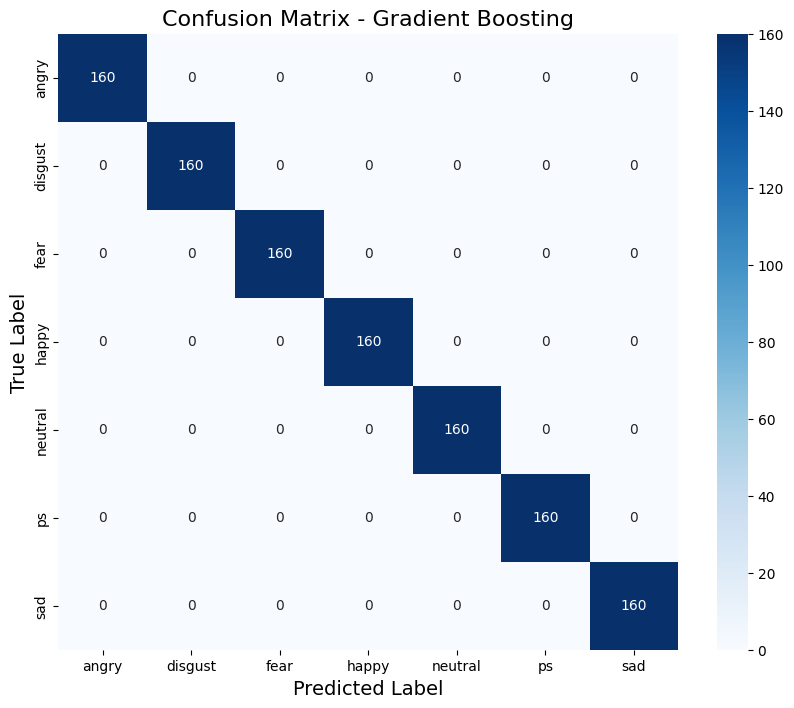


Classification Report - Gradient Boosting:
------------------------------------------------------------
              precision    recall  f1-score   support

       angry       1.00      1.00      1.00       160
     disgust       1.00      1.00      1.00       160
        fear       1.00      1.00      1.00       160
       happy       1.00      1.00      1.00       160
     neutral       1.00      1.00      1.00       160
          ps       1.00      1.00      1.00       160
         sad       1.00      1.00      1.00       160

    accuracy                           1.00      1120
   macro avg       1.00      1.00      1.00      1120
weighted avg       1.00      1.00      1.00      1120



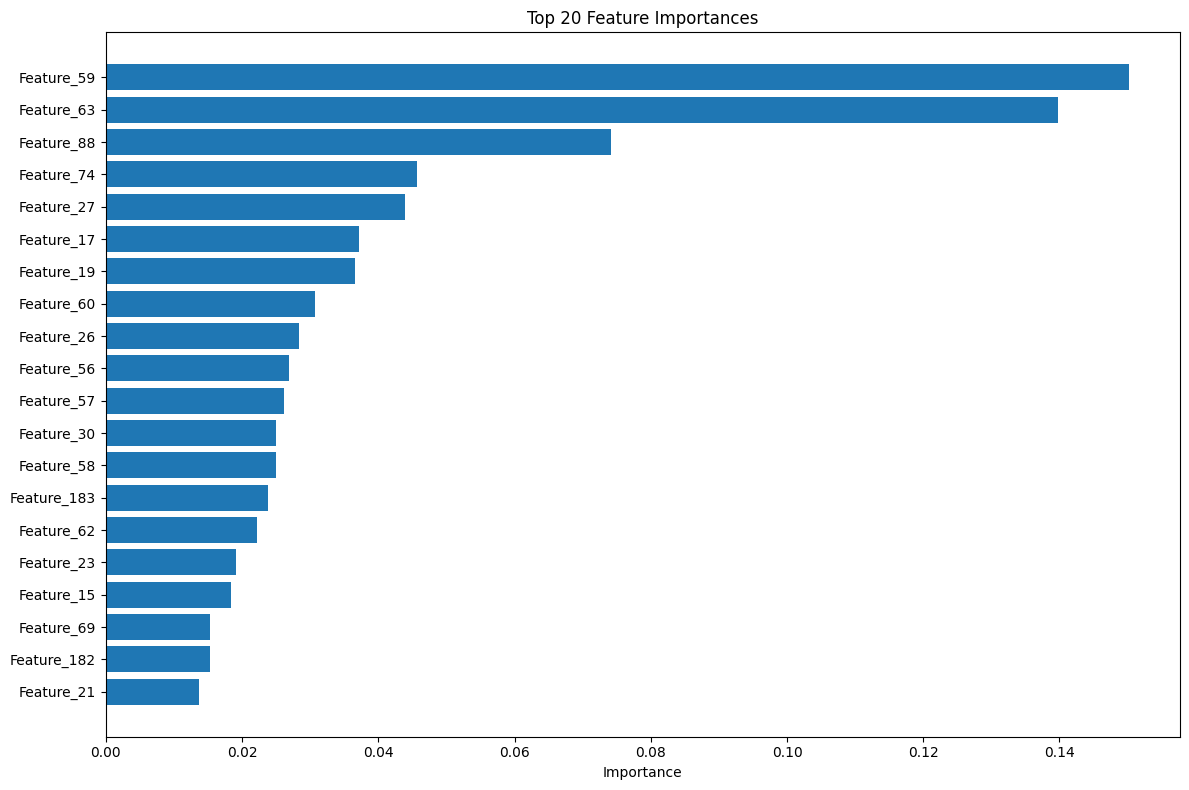

In [31]:
# NOW THIS WILL WORK: Use trained_classifiers (NOT models)
best_model_name = results_df.iloc[0]['Model']
best_model = trained_classifiers[best_model_name]  # CORRECT: using trained_classifiers

print(f"🏆 Best Model: {best_model_name}")


# Make predictions with best model
if best_model_name == 'Neural Network':
    y_pred_proba = best_model.predict_proba(X_test)
    y_pred = best_model.predict(X_test)
else:
    y_pred_proba = best_model.predict_proba(X_test)
    y_pred = best_model.predict(X_test)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, 
            annot=True, 
            fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.show()

# Classification Report
print(f"\nClassification Report - {best_model_name}:")
print("-" * 60)
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Feature Importance for tree-based models
if hasattr(best_model, 'feature_importances_'):
    # Get feature importance
    importances = best_model.feature_importances_
    
    # Get feature names (simplified)
    feature_names = [f'Feature_{i}' for i in range(len(importances))]
    
    # Create DataFrame
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    # Plot top 20 features
    plt.figure(figsize=(12, 8))
    top_features = feature_importance_df.head(20)
    plt.barh(range(len(top_features)), top_features['Importance'][::-1])
    plt.yticks(range(len(top_features)), top_features['Feature'][::-1])
    plt.xlabel('Importance')
    plt.title('Top 20 Feature Importances')
    plt.tight_layout()
    plt.show()


Cross-Validation Scores for Gradient Boosting:
  Scores: [1. 1. 1. 1. 1.]
  Mean: 1.0000
  Std: 0.0000


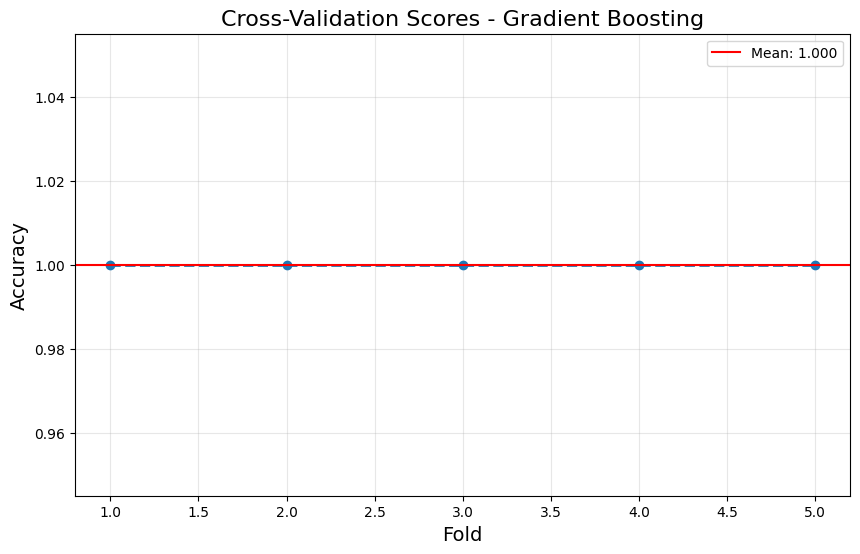

In [32]:
# Cross-validation for best model
cv_scores = cross_val_score(best_model, X_scaled, Y_encoded, cv=5)
print(f"\nCross-Validation Scores for {best_model_name}:")
print(f"  Scores: {cv_scores}")
print(f"  Mean: {cv_scores.mean():.4f}")
print(f"  Std: {cv_scores.std():.4f}")

# Plot cross-validation scores
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), cv_scores, marker='o', linestyle='--', linewidth=2)
plt.fill_between(range(1, 6), 
                  cv_scores.mean() - cv_scores.std(),
                  cv_scores.mean() + cv_scores.std(),
                  alpha=0.2)
plt.axhline(y=cv_scores.mean(), color='r', linestyle='-', label=f'Mean: {cv_scores.mean():.3f}')
plt.title(f'Cross-Validation Scores - {best_model_name}', fontsize=16)
plt.xlabel('Fold', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [33]:
# Define parameter grid for best model
if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
elif best_model_name == 'SVM':
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': [1, 0.1, 0.01, 0.001],
        'kernel': ['rbf', 'linear']
    }
else:
    print(f"Hyperparameter tuning not implemented for {best_model_name}")
    param_grid = None

if param_grid:
    # Perform Grid Search
    print(f"\nPerforming Grid Search for {best_model_name}...")
    grid_search = GridSearchCV(
        best_model,
        param_grid,
        cv=3,
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    print(f"\nBest Parameters: {grid_search.best_params_}")
    print(f"Best Cross-validation Score: {grid_search.best_score_:.4f}")
    
    # Test with best parameters
    best_tuned_model = grid_search.best_estimator_
    y_pred_tuned = best_tuned_model.predict(X_test)
    tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
    print(f"Test Accuracy with Tuned Model: {tuned_accuracy:.4f}")

Hyperparameter tuning not implemented for Gradient Boosting


In [34]:
import joblib
import json
from datetime import datetime

# Create timestamp for saving
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Create directory for saving models
import os
os.makedirs('saved_models', exist_ok=True)
os.makedirs('saved_results', exist_ok=True)

# Save best model
model_filename = f'saved_models/best_model_{timestamp}.pkl'
joblib.dump(best_model, model_filename)
print(f"Best model saved as: {model_filename}")

# Save scaler
scaler_filename = f'saved_models/scaler_{timestamp}.pkl'
joblib.dump(scaler, scaler_filename)
print(f"Scaler saved as: {scaler_filename}")

# Save label encoder
encoder_filename = f'saved_models/label_encoder_{timestamp}.pkl'
joblib.dump(le, encoder_filename)
print(f"Label encoder saved as: {encoder_filename}")

# Save LSTM model if it exists
lstm_filename = f'saved_models/lstm_model_{timestamp}.h5'
if 'lstm_model' in locals():
    lstm_model.save(lstm_filename)
    print(f"LSTM model saved as: {lstm_filename}")

# Save results to JSON
results_dict = {
    'best_model': best_model_name,
    'best_accuracy': float(results_df.iloc[0]['Accuracy']),
    'lstm_accuracy': float(lstm_accuracy) if 'lstm_accuracy' in locals() else None,
    'cv_mean': float(cv_scores.mean()),
    'cv_std': float(cv_scores.std()),
    'feature_count': int(X.shape[1]),
    'sample_count': int(X.shape[0]),
    'timestamp': timestamp,
    'classes': le.classes_.tolist()
}

results_filename = f'saved_results/results_{timestamp}.json'
with open(results_filename, 'w') as f:
    json.dump(results_dict, f, indent=4)
print(f"Results saved as: {results_filename}")

Best model saved as: saved_models/best_model_20251203_203306.pkl
Scaler saved as: saved_models/scaler_20251203_203306.pkl
Label encoder saved as: saved_models/label_encoder_20251203_203306.pkl
Results saved as: saved_results/results_20251203_203306.json


Testing with: speech dataset\TESS Toronto emotional speech set data\OAF_angry\OAF_back_angry.wav
Predicted Emotion: angry

Probability Distribution:
  angry: 1.000
  ps: 0.000
  disgust: 0.000
  happy: 0.000
  sad: 0.000
  neutral: 0.000
  fear: 0.000


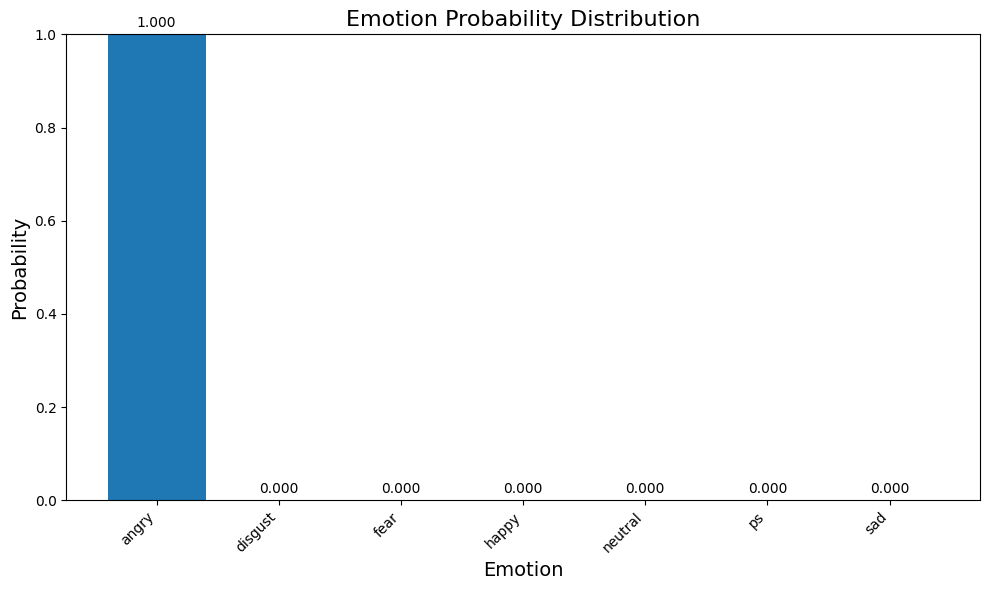

In [35]:
def predict_emotion(audio_path, model=best_model, scaler=scaler, encoder=le):
    """
    Predict emotion from a new audio file
    """
    try:
        # Extract features
        features = get_features(audio_path)
        
        # Scale features
        features_scaled = scaler.transform(features.reshape(1, -1))
        
        # Predict
        prediction = model.predict(features_scaled)
        probabilities = model.predict_proba(features_scaled)
        
        # Get class name
        class_idx = prediction[0]
        class_name = encoder.inverse_transform([class_idx])[0]
        
        # Get probabilities for all classes
        prob_dict = {encoder.classes_[i]: float(probabilities[0][i]) 
                     for i in range(len(encoder.classes_))}
        
        # Display results
        print(f"Predicted Emotion: {class_name}")
        print("\nProbability Distribution:")
        for emotion, prob in sorted(prob_dict.items(), key=lambda x: x[1], reverse=True):
            print(f"  {emotion}: {prob:.3f}")
        
        # Visualize probabilities
        plt.figure(figsize=(10, 6))
        emotions = list(prob_dict.keys())
        probs = list(prob_dict.values())
        
        bars = plt.bar(emotions, probs)
        plt.title('Emotion Probability Distribution', fontsize=16)
        plt.xlabel('Emotion', fontsize=14)
        plt.ylabel('Probability', fontsize=14)
        plt.ylim(0, 1)
        plt.xticks(rotation=45, ha='right')
        
        # Add probability values on bars
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                     f'{height:.3f}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
        # Play the audio
        display(Audio(audio_path))
        
        return class_name, prob_dict
        
    except Exception as e:
        print(f"Error processing audio: {e}")
        return None, None

# Test with a sample audio file
sample_audio = df['speech'].iloc[0]  # First audio file
print(f"Testing with: {sample_audio}")
predicted_emotion, probabilities = predict_emotion(sample_audio)

In [1]:
# If you have a new audio file to test
new_audio_path = "sad.wav"  # Replace with your file path

# Check if file exists
import os
if os.path.exists(new_audio_path):
    print(f"Testing custom file: {new_audio_path}")
    predicted_emotion, probabilities = predict_emotion(new_audio_path)
else:
    print(f"File not found: {new_audio_path}")
    
    # List available files in your dataset
    print("\nAvailable files in your dataset:")
    for i in range(5):  # Show first 5
        print(f"  {i}: {df['speech'].iloc[i]}")

Testing custom file: sad.wav


NameError: name 'predict_emotion' is not defined


PROJECT SUMMARY
               Metric         Value
        Total Samples          2800
   Number of Features           193
    Number of Classes             7
           Best Model Random Forest
        Best Accuracy        1.0000
        LSTM Accuracy        0.9982
Cross-Validation Mean        1.0000
 Cross-Validation Std        0.0000


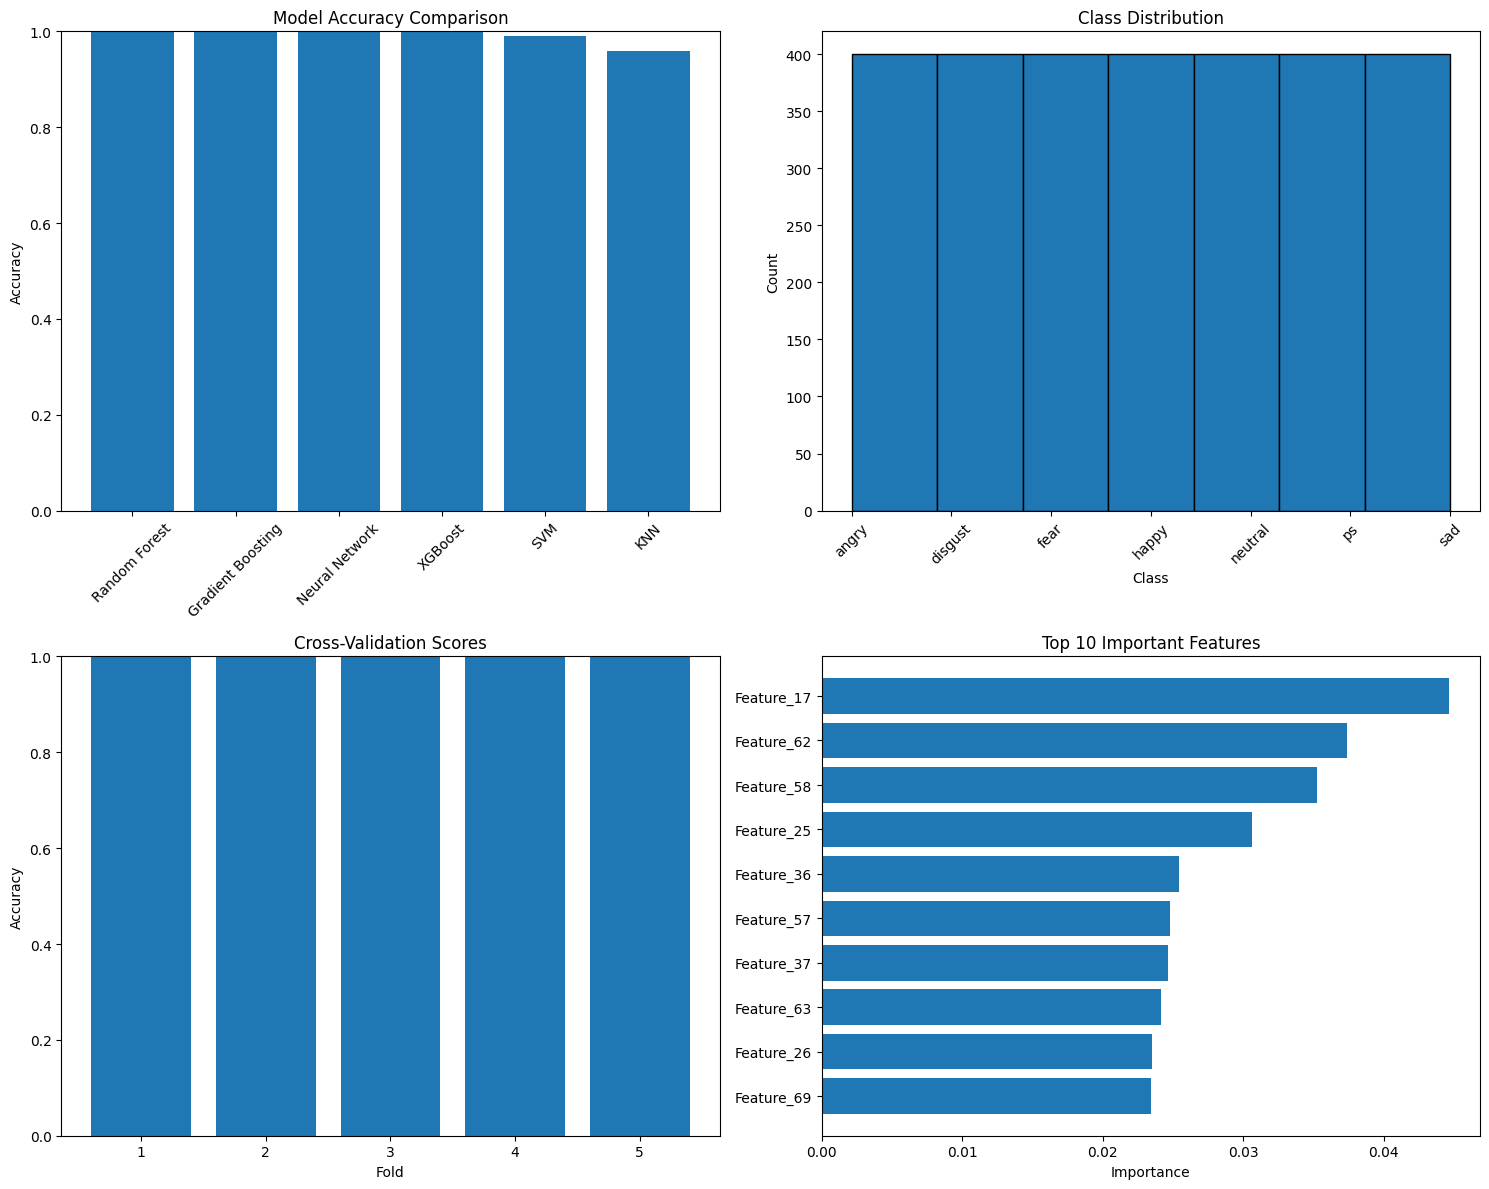


✅ Project Completed Successfully!
All models have been trained, evaluated, and saved.


In [ ]:
# Create summary dataframe
summary_df = pd.DataFrame({
    'Metric': [
        'Total Samples',
        'Number of Features',
        'Number of Classes',
        'Best Model',
        'Best Accuracy',
        'LSTM Accuracy',
        'Cross-Validation Mean',
        'Cross-Validation Std'
    ],
    'Value': [
        X.shape[0],
        X.shape[1],
        len(le.classes_),
        best_model_name,
        f"{results_df.iloc[0]['Accuracy']:.4f}",
        f"{lstm_accuracy:.4f}" if 'lstm_accuracy' in locals() else 'N/A',
        f"{cv_scores.mean():.4f}",
        f"{cv_scores.std():.4f}"
    ]
})

print("\n" + "="*50)
print("PROJECT SUMMARY")
print("="*50)
print(summary_df.to_string(index=False))

# Plot final comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Model comparison
axes[0, 0].bar(results_df['Model'], results_df['Accuracy'])
axes[0, 0].set_title('Model Accuracy Comparison')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].tick_params(axis='x', rotation=45)

# Class distribution
axes[0, 1].hist(Y_encoded, bins=len(le.classes_), edgecolor='black')
axes[0, 1].set_title('Class Distribution')
axes[0, 1].set_xlabel('Class')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_xticks(range(len(le.classes_)))
axes[0, 1].set_xticklabels(le.classes_, rotation=45)

# Cross-validation scores
axes[1, 0].bar(range(1, 6), cv_scores)
axes[1, 0].set_title('Cross-Validation Scores')
axes[1, 0].set_xlabel('Fold')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_ylim(0, 1)

# Feature importance (if available)
if 'feature_importance_df' in locals():
    top_10 = feature_importance_df.head(10)
    axes[1, 1].barh(top_10['Feature'][::-1], top_10['Importance'][::-1])
    axes[1, 1].set_title('Top 10 Important Features')
    axes[1, 1].set_xlabel('Importance')

plt.tight_layout()
plt.show()


print("All models have been trained, evaluated, and saved.")